database "bmw global sales"
Goal: learn how to EDA in database
all comments was done by me to understand all steps of work with EDA

importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
#styling of tables and graphics
plt.rcParams['figure.figsize'] = [10, 10] # after that graphics wil be 10*10 inches
sns.set_style('whitegrid') # making the background of all graphics into white grid

In [4]:
df = pd.read_csv('bmw_global_sales_2018_2025.csv') # reading database and creating dataframe for it




In [5]:
df.head() #return first 5 strings of dataframe
df.tail()#return last 5 strings of dataframe
df.info() # return info about your dataframe (names of coloumns, datatypes, non-nul values)
df.shape # return shape of dataframe in a tuple

<class 'pandas.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   str    
 3   Model             3072 non-null   str    
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), str(2)
memory usage: 264.1 KB


(3072, 11)

In [6]:
print('-' * 50)
print("Unique regions")
df['Region'].unique() # print amount of "unique" regions from coloumn 'Region'



--------------------------------------------------
Unique regions


<StringArray>
['Europe', 'China', 'USA', 'RestOfWorld']
Length: 4, dtype: str

In [7]:
print('-' * 50)
print("Unique models")
df['Model'].unique() # print amount of "unique" models from coloumn 'Model'

--------------------------------------------------
Unique models


<StringArray>
['3 Series', '5 Series', 'X3', 'X5', 'X7', 'i4', 'iX', 'MINI']
Length: 8, dtype: str

In [8]:
print('-'*50)
df.describe() # return statistics about numeric coloumns

--------------------------------------------------


,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


In [9]:
#checking negative elements in 'BEV_Share'
negative = df[df['BEV_Share']<0] #amount of negative elements

if len(negative) > 0 :
    print("Negative data")
    print(negative) # printing where dataframe has negative (wrong) values



Negative data
     Year  Month       Region Model  Units_Sold  Avg_Price_EUR  Revenue_EUR  \
158  2018      5  RestOfWorld    iX        8853          76249    675032397   
174  2018      6        China    iX        8223          73770    606610710   
186  2018      6  RestOfWorld    X3        4846          58895    285405170   
212  2018      7          USA    X7        5923          92595    548440185   
223  2018      7  RestOfWorld  MINI        8111          41673    338009703   
238  2018      8        China    iX        6192          75626    468276192   
275  2018      9          USA    X5        8505          69161    588214305   
292  2018     10       Europe    X7        3590          92987    333823330   
356  2018     12       Europe    X7       10765          92682    997721730   

     BEV_Share  Premium_Share  GDP_Growth  Fuel_Price_Index  
158     -0.001           5.15        3.84              0.97  
174     -0.015          20.05        2.89              1.00  
186     -

In [10]:
df['BEV_Share'] = df['BEV_Share'].apply(lambda x: 0 if x < 0 else x)
print(f"\nChecking min in BEV_Share {df['BEV_Share'].min()}")


Checking min in BEV_Share 0.0


In [11]:
df['BEV_Share'] = df['BEV_Share'] * 100 #now BEV_Share is also in percents as Premium_Share
df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,10.758431,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,5.807550,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,0.000000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,5.700000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,10.800000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,15.725000,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,22.300000,20.970000,5.820000,1.410000


In [12]:
#work with duplicates
full_duplicates = df.duplicated().sum()
print(full_duplicates)
logic_dupl =  df.duplicated(subset=['Year', 'Month', 'Region', 'Model']).sum()
print(logic_dupl)

if full_duplicates > 0 or logic_dupl > 0:
    df.drop_duplicates(subset=['Year', 'Month', 'Region', 'Model'])


0
0


In [13]:


#creating dataframe with omissions
demo = pd.DataFrame({
    'Price': [40000, 45000, np.nan, 50000],
    'Region': ['Europe', np.nan, 'Asia', 'Europe']
})

# filling omissions with mean value of parametr
demo['Price_mean'] = demo['Price'].fillna(demo['Price'].mean())

# filling omissions with median value of parametr
demo['Price_median'] = demo['Price'].fillna(demo['Price'].median())

# filling omissions with moda value of parametr
demo['Region_mode'] = demo['Region'].fillna(demo['Region'].mode()[0])


print("\nResult:")
display(demo)

#also we can use dropna(); e.g.: use to delete coloumns(strings) with nan, but i will use it only if i willdecide that 
# these data isn't too nesessary or it won't harm this dataset 


Result:


,Price,Region,Price_mean,Price_median,Region_mode
0,40000.0,Europe,40000.0,40000.0,Europe
1,45000.0,NaN,45000.0,45000.0,Europe
2,NaN,Asia,45000.0,45000.0,Asia
3,50000.0,Europe,50000.0,50000.0,Europe


In [14]:
#working with statistics min, max, mode etc.

numeric_cols = df.select_dtypes(include=[np.number]).columns #df only with numeric columns


for col in numeric_cols:
    print(f"\n Column: {col}")
    print("-" * 80)
    
    print(f"{'Min':<20} {df[col].min():>15,.2f}")# min of category
    print(f"{'Max':<20} {df[col].max():>15,.2f}")# max of category
    print(f"{'Mean':<20} {df[col].mean():>15,.2f}")# mean of category
    print(f"{'Median':<20} {df[col].median():>15,.2f}")# median of category
    print(f"{'Mode':<20} {df[col].mode().iloc[0]:>15,.2f}")# mode of category (return first one)
    
    print(f"\n{'Percentiles:':<20}")# counting percentiles (5, 25, 50, 75, 95)
    print(f"  5%:  {df[col].quantile(0.05):>15,.2f}")
    print(f"  25%: {df[col].quantile(0.25):>15,.2f}")
    print(f"  50%: {df[col].quantile(0.50):>15,.2f}")
    print(f"  75%: {df[col].quantile(0.75):>15,.2f}")
    print(f"  95%: {df[col].quantile(0.95):>15,.2f}")
    
    print(f"\n{'Extended stats:':<20}")
    print(f"  Variance:  {df[col].var():>15,.2f}") # Мера разброса данных (в квадрате)
    print(f"  Std Dev:  {df[col].std():>15,.2f}") # Мера разброса данных (в той же размерности)
    print(f"  Skewness: {stats.skew(df[col]):>15,.4f}") # Показывает "скошенность" распределения
    print(f"  Kurtosis:    {stats.kurtosis(df[col]):>15,.4f}") # Показывает "остроту" пика

    
    skew = stats.skew(df[col])  # определяем распределение (норма, или есть выбросы)
    if abs(skew) < 0.5:
        skew_interp = "≈ symetrical"
    elif skew > 0:
        skew_interp = "→ tail in right "
    else:
        skew_interp = "← tail in left"
    
    print(f"\n💡 Distribution: {skew_interp}")


 Column: Year
--------------------------------------------------------------------------------
Min                         2,018.00
Max                         2,025.00
Mean                        2,021.50
Median                      2,021.50
Mode                        2,018.00

Percentiles:        
  5%:         2,018.00
  25%:        2,019.75
  50%:        2,021.50
  75%:        2,023.25
  95%:        2,025.00

Extended stats:     
  Variance:             5.25
  Std Dev:             2.29
  Skewness:          0.0000
  Kurtosis:            -1.2381

💡 Distribution: ≈ symetrical

 Column: Month
--------------------------------------------------------------------------------
Min                             1.00
Max                            12.00
Mean                            6.50
Median                          6.50
Mode                            1.00

Percentiles:        
  5%:             1.00
  25%:            3.75
  50%:            6.50
  75%:            9.25
  95%:           1

In [15]:
# one_hot encoding

display(df[['Region', 'Model']].head) # what we had at first

df_encoded = df.copy()

df_encoded = pd.get_dummies(
    df_encoded,
    columns = ['Region', 'Model'],# columns for encoding 
    prefix = ['Reg', 'Mod'], # prefix for new columns
    drop_first = True # drop old columns
)

new_cols = [c for c in df_encoded.columns if c.startswith('Reg_') or c.startswith('Mod_')]# finding all colums with names that are starting with Reg_ and Mod_
display(df_encoded[new_cols].head) # what we had after encoding

<bound method NDFrame.head of            Region     Model
0          Europe  3 Series
1          Europe  5 Series
2          Europe        X3
3          Europe        X5
4          Europe        X7
...           ...       ...
3067  RestOfWorld        X5
3068  RestOfWorld        X7
3069  RestOfWorld        i4
3070  RestOfWorld        iX
3071  RestOfWorld      MINI

[3072 rows x 2 columns]>

<bound method NDFrame.head of       Reg_Europe  Reg_RestOfWorld  Reg_USA  Mod_5 Series  Mod_MINI  Mod_X3  \
0           True            False    False         False     False   False   
1           True            False    False          True     False   False   
2           True            False    False         False     False    True   
3           True            False    False         False     False   False   
4           True            False    False         False     False   False   
...          ...              ...      ...           ...       ...     ...   
3067       False             True    False         False     False   False   
3068       False             True    False         False     False   False   
3069       False             True    False         False     False   False   
3070       False             True    False         False     False   False   
3071       False             True    False         False      True   False   

      Mod_X5  Mod_X7  Mod_i4  Mod

In [16]:
#Feature engeneering
#creating column with revenue per unit
df['Revenue_Per_Unit'] = df['Revenue_EUR'] / df['Units_Sold'] 
display(df['Revenue_Per_Unit'])

0       47482.0
1       61685.0
2       58433.0
3       67955.0
4       92300.0
         ...   
3067    68198.0
3068    91839.0
3069    63437.0
3070    73867.0
3071    41811.0
Name: Revenue_Per_Unit, Length: 3072, dtype: float64

In [17]:
#creating column with specific (rare) models
model_counts = df['Model'].value_counts()
rare_models = model_counts[model_counts < 100].index

df['Model_Grouped'] = df['Model'].apply(
    lambda x: 'Other' if x in rare_models else x
)

display(df['Model_Grouped'].value_counts())
# this dataset has all modells in equal amount, so we don't need to create column where we 
# can place rare models
#this part has done just for practice

Model_Grouped
3 Series    384
5 Series    384
X3          384
X5          384
X7          384
i4          384
iX          384
MINI        384
Name: count, dtype: int64

In [18]:
# creating a columns that will consist of budget models and premium models

df['Prices_Category'] = pd.cut(
    df['Avg_Price_EUR'],
    bins=[0, 45000, 65000, float('inf')],
    labels=['Budget', 'Medium', 'Premium']
)

display(df['Prices_Category'].head(10))

0     Medium
1     Medium
2     Medium
3    Premium
4    Premium
5     Medium
6    Premium
7     Budget
8     Medium
9     Medium
Name: Prices_Category, dtype: category
Categories (3, str): ['Budget' < 'Medium' < 'Premium']

In [20]:
# creating column with quarters (consists of three monthes)
df['Quarter'] = (df['Month']-1) // 3 + 1 
display(df['Quarter'])

0       1
1       1
2       1
3       1
4       1
       ..
3067    4
3068    4
3069    4
3070    4
3071    4
Name: Quarter, Length: 3072, dtype: int64

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Year              3072 non-null   int64   
 1   Month             3072 non-null   int64   
 2   Region            3072 non-null   str     
 3   Model             3072 non-null   str     
 4   Units_Sold        3072 non-null   int64   
 5   Avg_Price_EUR     3072 non-null   int64   
 6   Revenue_EUR       3072 non-null   int64   
 7   BEV_Share         3072 non-null   float64 
 8   Premium_Share     3072 non-null   float64 
 9   GDP_Growth        3072 non-null   float64 
 10  Fuel_Price_Index  3072 non-null   float64 
 11  Revenue_Per_Unit  3072 non-null   float64 
 12  Model_Grouped     3072 non-null   str     
 13  Prices_Category   3072 non-null   category
 14  Quarter           3072 non-null   int64   
dtypes: category(1), float64(5), int64(6), str(3)
memory usage: 339.2 KB


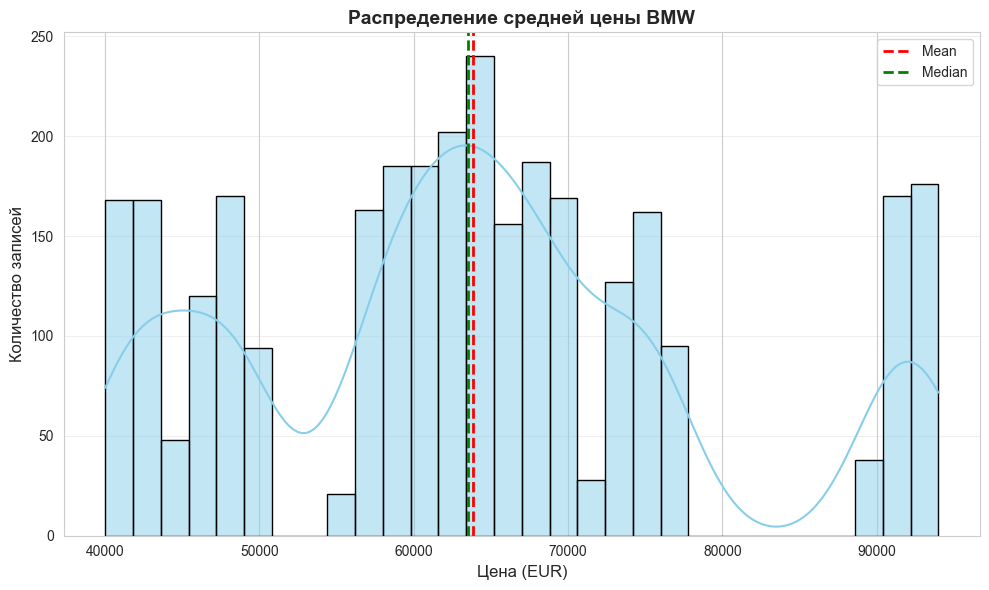

In [ ]:
# histogramm
plt.figure(figsize=(10,6))# configuring plot's field

sns.histplot(       #configuring plot
    df,
    x='Avg_Price_EUR',
    bins=30,
    kde=True,
    color='skyblue',
    edgecolor='black'
)
# name of plot
plt.title('Распределение средней цены BMW', fontsize=14, fontweight='bold')
#names of axes
plt.xlabel('Цена (EUR)', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)

# creating lines of median and mean
plt.axvline(df['Avg_Price_EUR'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
plt.axvline(df['Avg_Price_EUR'].median(), color='green', linestyle='--', linewidth=2, label='Median')

plt.legend() # forming legend of plot
plt.grid(axis='y', alpha=0.3)# adding grid on plot on Y axis
plt.tight_layout()# auto aligning of legend and labels on plot
plt.show()# output

### Выводы по гистограмме:
1) распределение мультимодальное
2) разница между mean и median мала, распределение симметрично
3) распределение по ценовым сегментам:
    - 40k-50k 
    - 55k-78k
    - 90k+
4) пробелы между сегментами указывают на четкое сегментирование моделей по ценам
5) наибольшее кол-во моделей приходится на средний ценовой сегмент

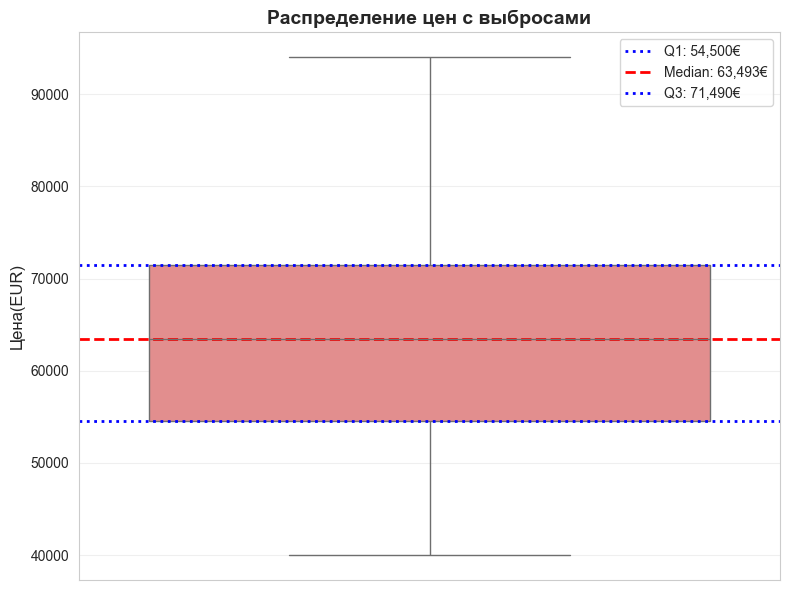

In [28]:
# boxplot

plt.figure(figsize=(8, 6))

sns.boxplot(
    df,
    y='Avg_Price_EUR',
    color='lightcoral'
)

plt.title('Распределение цен с выбросами', fontsize=14, fontweight='bold')
plt.ylabel('Цена(EUR)', fontsize=12)

Q1 = df['Avg_Price_EUR'].quantile(0.25)# 25%
Q3 = df['Avg_Price_EUR'].quantile(0.75)# 75%
median = df['Avg_Price_EUR'].median()# median

# configiring plot
plt.axhline(Q1, color='blue', linestyle=':', linewidth=2, label=f'Q1: {Q1:,.0f}€')
plt.axhline(median, color='red', linestyle='--', linewidth=2, label=f'Median: {median:,.0f}€')
plt.axhline(Q3, color='blue', linestyle=':', linewidth=2, label=f'Q3: {Q3:,.0f}€')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Выводы по boxplot
1) IQR = Q3-Q1 = 16 990€
2) выбросов нет
3) положение медианы симметричное 
4) нижний ус немного  короче верхнего, что указывает на большее кол-во моделей из премиум сегмента, но не влияет на симметричность
Нижний ус до Q1:  54 500 - 40 000 = 14 500 €
Q3 до верхнего уса: 94 000 - 71 490 = 22 510 €

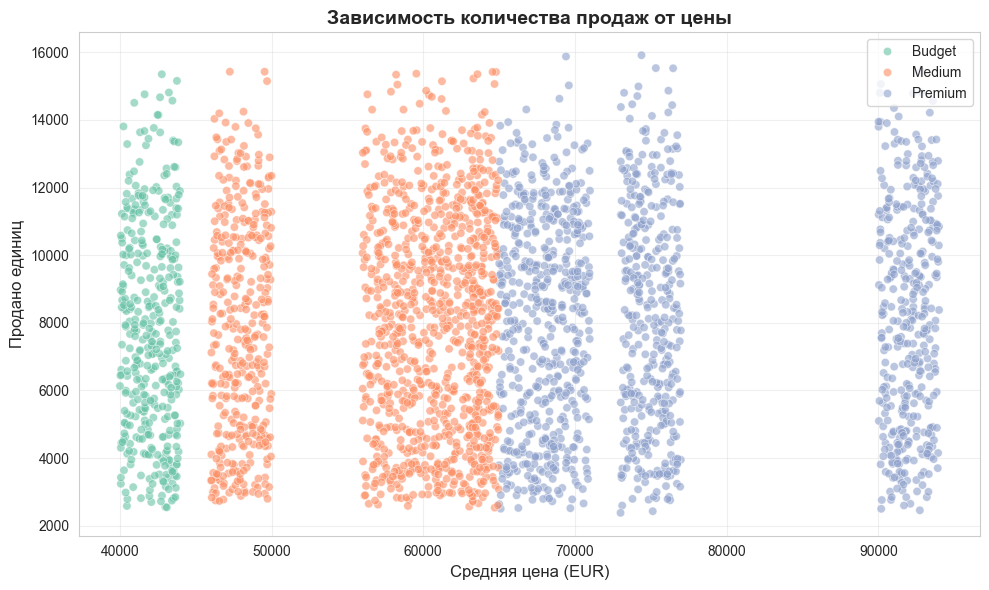

In [32]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    df,
    x='Avg_Price_EUR',
    y='Units_Sold',
    alpha=0.6,
    hue='Prices_Category' if 'Prices_Category' in df.columns else None,
    palette='Set2'
)

plt.title('Зависимость количества продаж от цены', fontsize=14, fontweight='bold')
plt.xlabel('Средняя цена (EUR)', fontsize=12)
plt.ylabel('Продано единиц', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Вывод по scatterplot
1) корелляции нет или она слабая (продажи +- одинаковы вне зависимости от сегмента)
2) по графику видно что выделяется 6 ценовых кластеров
    - 40k-45k
    - 47k - 50k
    - 56k - 65k
    - 66k - 71k
    - 73k - 78k
    - 90k - 94k
3) цена не является определяющей в объяеме продаж, скорее всего на это влияют другие факторы(регион, цена на топливо и др.)

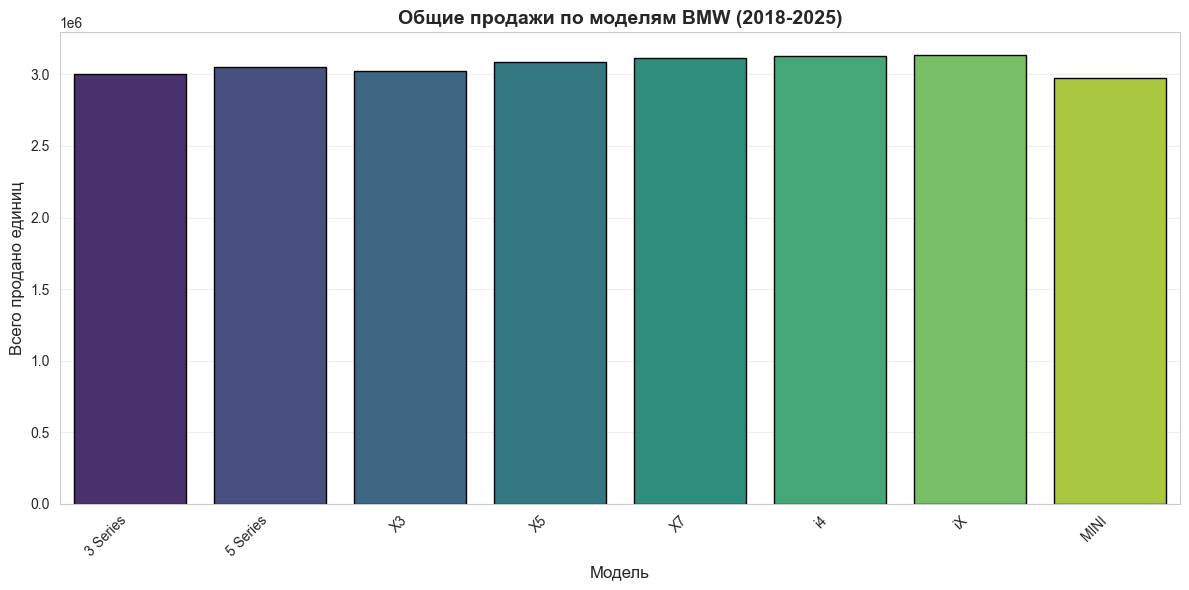

In [34]:
plt.figure(figsize=(12, 6))

sns.barplot(
    df,
    x='Model',
    y='Units_Sold',
    hue='Model',
    estimator='sum', # give sum, not mean
    palette='viridis',
    edgecolor='black',
    errorbar=None, # delete error rates
    legend=False
)

plt.title('Общие продажи по моделям BMW (2018-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Модель', fontsize=12)
plt.ylabel('Всего продано единиц', fontsize=12)

plt.xticks(rotation=45, ha='right') # aligning of labels in plot

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



### Выводы по barplot
1) кол-во продаж не зависит от моели существенно
2) топ моделей по продажам:
    - x7
    - i4
    - ix
3) худшая модель по продажам MINI
4) поляризация спроса слабая

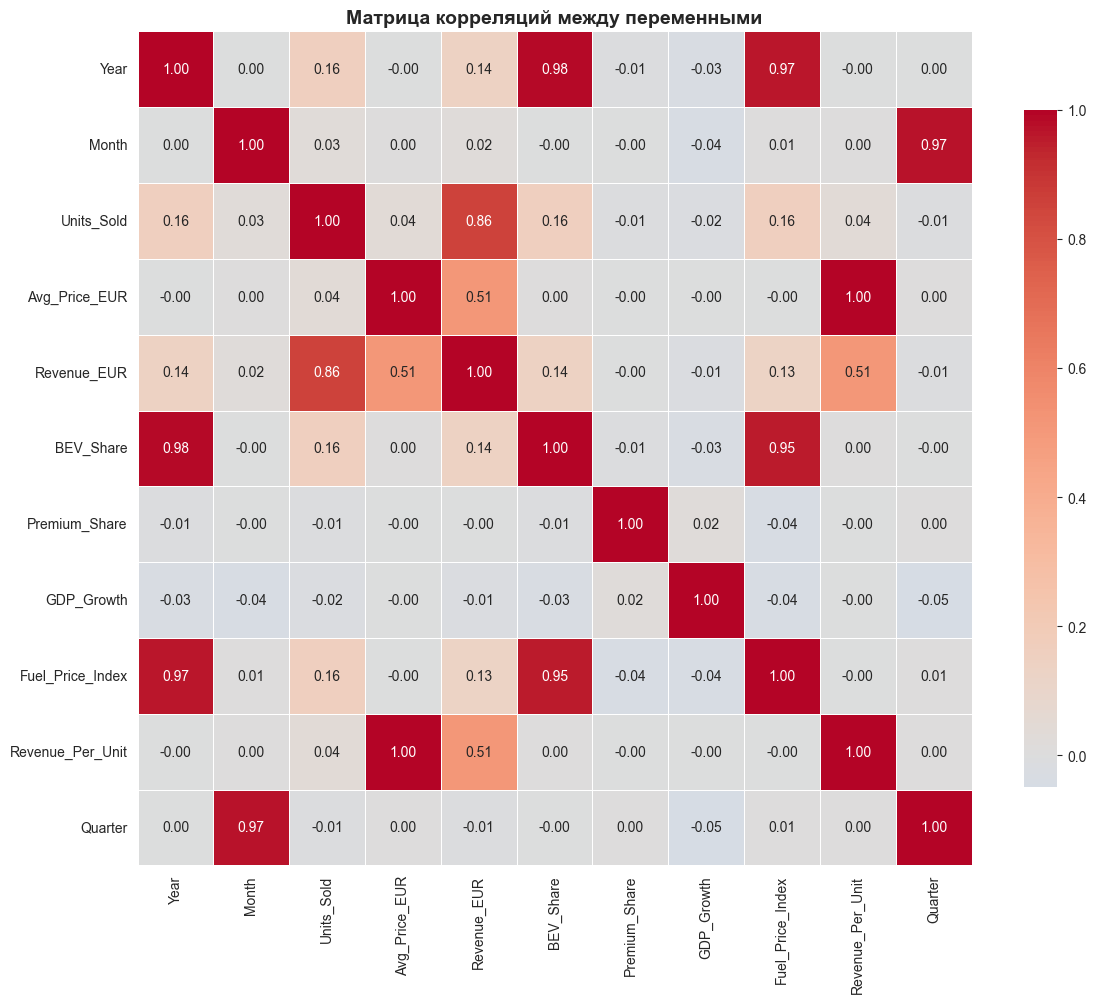


СИЛЬНЫЕ КОРРЕЛЯЦИИ (> |0.7|):
   Revenue_EUR ↔ Units_Sold: 0.856
   BEV_Share ↔ Year: 0.985
   Fuel_Price_Index ↔ Year: 0.966
   Fuel_Price_Index ↔ BEV_Share: 0.952
   Revenue_Per_Unit ↔ Avg_Price_EUR: 1.000
   Quarter ↔ Month: 0.972

Умеренные корреляции (0.5 - 0.7):
   Revenue_EUR - Avg_Price_EUR: 0.513
   Revenue_Per_Unit - Revenue_EUR: 0.513


In [38]:
#heatmap

numeric_columns = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    linewidth=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Матрица корреляций между переменными', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# analisys of correlation

strong_corr=[]

for i in range(len(corr_matrix.columns)):
    for j in range(i):  
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:  
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            strong_corr.append((col1, col2, corr_value))
            
if strong_corr:
    print("\nСИЛЬНЫЕ КОРРЕЛЯЦИИ (> |0.7|):")
    for col1, col2, val in strong_corr:
        print(f"   {col1} ↔ {col2}: {val:.3f}")
else:
    print("\nСильных корреляций (> |0.7|) не обнаружено")

print("\nУмеренные корреляции (0.5 - 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]
        if 0.5 <= abs(corr_value) <= 0.7:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            print(f"   {col1} - {col2}: {corr_value:.3f}")

### Выводы по heatmap
1) Revenue_Per_Unit ↔ Avg_Price_EUR, corr = 1, это значит что данные две переменные избыточны, можно удалить одну из них
2) BEV_Share ↔ Year: 0.985, рост кол-во продаваемых электромобилий
3) Fuel_Price_Index ↔ BEV_Share: 0.952, можно предположить, что спрос на электромобили растет из-за дорожания бензина и дизеля
4) Quarter ↔ Month: 0.972, quarter считается через Month, поэтому корреляция была очевидно, но quarter удобнее, можно удалить month
5) как было видно в предыдущих графиках, цена не влияет на кол-во продаж

In [40]:
# график полностью с ИИ, взял для себя чтобы ознакомиться и разобраться, стало интересно посмотреть
# на возможности данной библиотеки

import plotly.express as px  # Импорт библиотеки

fig = px.scatter(
    df, 
    x='Avg_Price_EUR', 
    y='Units_Sold',
    color='Model',              # Цвет точек по модели
    size='Revenue_EUR',         # Размер точки = выручка
    hover_data=['Year', 'Region', 'BEV_Share'],  # Данные при наведении
    title='Продажи BMW: Цена vs Количество (интерактивный)',
    labels={
        'Avg_Price_EUR': 'Средняя цена (EUR)', 
        'Units_Sold': 'Продано единиц'
    },
    height=600,                 # Высота графика в пикселях
    width=1000                  # Ширина графика в пикселях
)

# Улучшаем оформление
fig.update_layout(
    font=dict(size=12),
    hovermode='closest',        # Показывать данные ближайшей точки
    legend_title_text='Модель',
    title_font_size=16,
    title_x=0.5                 # Центрировать заголовок
)

# Показываем график
fig.show()

### Итоги
1) анализ графиков и dataset приведен сразу после графиков
2) ИИ использовал везде для пояснения кода, инструкций в выполнении этапов, но код писал самостоятельно (просто с его набросков); все комментарии сделаны мной самим
### Что дальше
1) модель - не знаю
2) Удалить сильно коррелирующие показатели, об этом писал после heatmap